# Ejemplo 1 — PINN para la ecuación de Poisson con fuente oscilatoria

### Capítulo 6, Sección 6.3 — *AI for PDEs / Physics-Informed Neural Networks*

Este cuaderno replica el **Ejemplo 1** de la Sección 6.3: resolver un problema directo de Poisson mediante una red neuronal informada por física (**PINN**). El flujo sigue el patrón pedagógico del cuaderno de referencia: formulación matemática, generación/visualización del problema, muestreo sin malla, definición del PINN, entrenamiento y validación.

La ecuación del ejemplo es

$$-
\nabla^2 u(x,y)=f(x,y),\qquad (x,y)\in\Omega,$$

con condición de Dirichlet

$$u(x,y)=g(x,y),\qquad (x,y)\in \partial\Omega.$$

En la prueba estándar del libro se usa una fuente altamente oscilatoria:

$$f(x,y)=50\sin(20\pi x)\sin(20\pi y).$$

Para poder medir el error de forma honesta, trabajamos primero en $\Omega=[0,1]^2$ con condición de frontera homogénea. En ese caso existe una solución exacta sencilla:

$$u_\star(x,y)=\frac{50}{2(20\pi)^2}\sin(20\pi x)\sin(20\pi y).$$

La red **no usa** esa solución exacta para entrenar; solo la usamos al final para validar, porque un cuaderno sin validación es un adorno muy bonito, pero bastante inútil.


**Cómo usarlo.** Ejecute las celdas de arriba hacia abajo. En Colab conviene activar GPU: *Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU*. El entrenamiento usa derivadas de segundo orden por diferenciación automática, así que en CPU puede tardar más.

El parámetro `USE_FOURIER_FEATURES` está activado por defecto para que la red capture la fuente $\sin(20\pi x)\sin(20\pi y)$ sin convertir la clase en penitencia. Si quiere el MLP tanh puro, tal como se enuncia en el diseño mínimo del libro, póngalo en `False`; la formulación PINN no cambia.


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

np.random.seed(7)
torch.manual_seed(7)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| dispositivo:', device)


PyTorch 2.11.0+cu128 | dispositivo: cuda


## 1. Problema directo de Poisson

Tomamos el dominio cuadrado

$$\Omega=[0,1]^2,$$

y la fuente del ejemplo:

$$f(x,y)=50\sin(20\pi x)\sin(20\pi y).$$

Como $\sin(20\pi x)$ y $\sin(20\pi y)$ se anulan en la frontera del cuadrado, imponemos

$$g(x,y)=0\quad\text{en}\quad \partial\Omega.$$

La PINN aproxima $u$ mediante una red $\widehat u(x,y;\theta)$ y penaliza dos cosas:

$$\mathcal L_f(\theta)=\frac1{N_f}\sum_{i=1}^{N_f}\left|-\nabla^2\widehat u(x_f^i,y_f^i;\theta)-f(x_f^i,y_f^i)\right|^2,$$

$$\mathcal L_b(\theta)=\frac1{N_b}\sum_{i=1}^{N_b}\left|\widehat u(x_b^i,y_b^i;\theta)-g(x_b^i,y_b^i)\right|^2,$$

por tanto

$$\mathcal L(\theta)=\lambda_f\mathcal L_f+\lambda_b\mathcal L_b.$$

La parte fina, y por eso los PINNs son tan cómodos aquí, es que $\nabla^2\widehat u=\widehat u_{xx}+\widehat u_{yy}$ se calcula con **autograd**, sin armar matrices de diferencias finitas ni mallas FEM.


In [ ]:
pi = np.pi
FREQ = 10                         # sin(20*pi*x) = sin(2*pi*10*x)
K = 2*pi*FREQ
SOURCE_AMPLITUDE = 50.0
U_AMPLITUDE = SOURCE_AMPLITUDE / (2*K**2)

# Hiperparámetros principales del ejemplo
N_f = 10000                         # puntos interiores de residuo
N_b_edge = 250                     # puntos por lado de la frontera
USE_FOURIER_FEATURES = True        # ayuda a representar la oscilación alta
USE_LBFGS_AFTER_ADAM = True       # póngalo en True para refinar más

# En GPU podemos entrenar más; en CPU dejamos una versión razonable.
N_STEPS = 7000 if device.type == 'cuda' else 1800
PRINT_EVERY = max(300, N_STEPS // 5)

def u_exact_np(x, y):
    return U_AMPLITUDE * np.sin(K*x) * np.sin(K*y)

def f_source_np(x, y):
    return SOURCE_AMPLITUDE * np.sin(K*x) * np.sin(K*y)

def to_col(a, requires_grad=False):
    t = torch.tensor(a, dtype=torch.float32, device=device).reshape(-1, 1)
    return t.requires_grad_(requires_grad)

def f_source_torch(x, y):
    return SOURCE_AMPLITUDE * torch.sin(K*x) * torch.sin(K*y)

print('amplitud de la solución exacta:', U_AMPLITUDE)
print('iteraciones Adam:', N_STEPS, '| Fourier features:', USE_FOURIER_FEATURES)


amplitud de la solución exacta: 0.006332573977646111
iteraciones Adam: 7000 | Fourier features: True


## 2. Visualización del problema

Antes de entrenar, miramos la fuente $f$ y la solución exacta $u_\star$ que usaremos únicamente como referencia de validación.


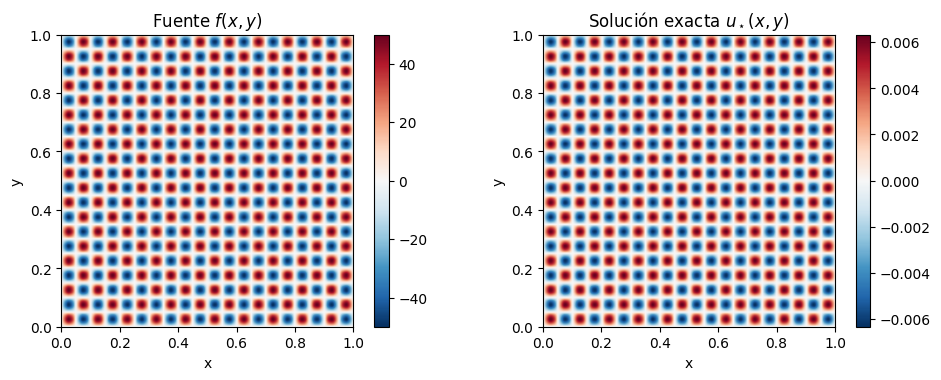

In [ ]:
n_plot = 250
xv = np.linspace(0, 1, n_plot)
yv = np.linspace(0, 1, n_plot)
X, Y = np.meshgrid(xv, yv, indexing='xy')
F = f_source_np(X, Y)
U_star = u_exact_np(X, Y)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))
im0 = axs[0].imshow(F, origin='lower', extent=[0, 1, 0, 1], cmap='RdBu_r')
axs[0].set_title(r'Fuente $f(x,y)$')
axs[0].set_xlabel('x'); axs[0].set_ylabel('y')
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(U_star, origin='lower', extent=[0, 1, 0, 1], cmap='RdBu_r')
axs[1].set_title(r'Solución exacta $u_\star(x,y)$')
axs[1].set_xlabel('x'); axs[1].set_ylabel('y')
fig.colorbar(im1, ax=axs[1])
plt.tight_layout(); plt.show()


## 3. Muestreo sin malla

La ventaja práctica del enfoque PINN es que no necesitamos una malla estructurada. Solo tomamos:

- puntos interiores $(x_f,y_f)$ para el residuo de la EDP;
- puntos de frontera $(x_b,y_b)$ para imponer la condición de Dirichlet.

Esto reproduce la idea del texto: para geometrías complicadas no se genera una malla FEM; se muestrean coordenadas.


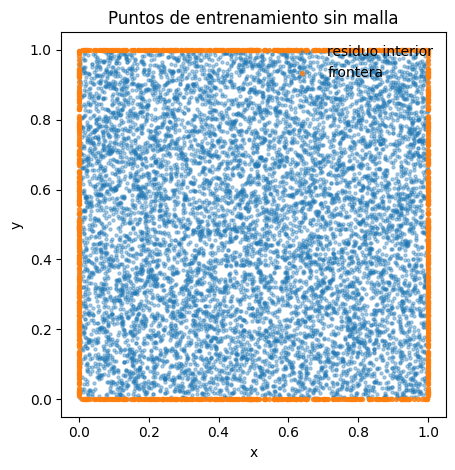

In [ ]:
# Puntos interiores para el residuo
xf = np.random.rand(N_f)
yf = np.random.rand(N_f)

# Puntos de frontera: cuatro lados del cuadrado
s = np.random.rand(N_b_edge)
xb = np.concatenate([
    np.zeros(N_b_edge),
    np.ones(N_b_edge),
    s,
    s,
])
yb = np.concatenate([
    s,
    s,
    np.zeros(N_b_edge),
    np.ones(N_b_edge),
])
ub = u_exact_np(xb, yb)             # aquí es cero, pero lo escribimos general

x_f = to_col(xf, requires_grad=True)
y_f = to_col(yf, requires_grad=True)
x_b = to_col(xb)
y_b = to_col(yb)
u_b = to_col(ub)

plt.figure(figsize=(4.8, 4.8))
plt.scatter(xf, yf, s=5, alpha=0.35, label='residuo interior')
plt.scatter(xb, yb, s=8, alpha=0.8, label='frontera')
plt.gca().set_aspect('equal')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Puntos de entrenamiento sin malla')
plt.legend(frameon=False, loc='upper right')
plt.tight_layout(); plt.show()


## 4. Arquitectura de la PINN

La red recibe $(x,y)$ y devuelve un escalar $\widehat u(x,y)$. Las capas ocultas usan `tanh`, tal como se acostumbra en PINNs porque produce salidas suaves y derivables.

Para la fuente altamente oscilatoria se agrega, por defecto, una codificación de Fourier de las coordenadas. No cambia la pérdida física; solo le da a la red una forma menos torpe de representar altas frecuencias. Sí, hasta una red necesita que uno no la sabotee desde la entrada.


In [ ]:
class MLP(nn.Module):
    def __init__(self, width=64, depth=4, use_fourier=True, freqs=(1, 2, 5, 10)):
        super().__init__()
        self.use_fourier = use_fourier
        self.register_buffer('freqs', torch.tensor(freqs, dtype=torch.float32).reshape(1, -1))
        in_dim = 2 + 4*len(freqs) if use_fourier else 2
        dims = [in_dim] + [width]*depth + [1]
        mods = []
        for i in range(len(dims) - 1):
            mods.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                mods.append(nn.Tanh())
        self.net = nn.Sequential(*mods)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def encode(self, x, y):
        if not self.use_fourier:
            return torch.cat([x, y], dim=1)
        sx = torch.sin(2*pi*x*self.freqs); cx = torch.cos(2*pi*x*self.freqs)
        sy = torch.sin(2*pi*y*self.freqs); cy = torch.cos(2*pi*y*self.freqs)
        return torch.cat([x, y, sx, cx, sy, cy], dim=1)

    def forward(self, x, y):
        return self.net(self.encode(x, y))

net = MLP(use_fourier=USE_FOURIER_FEATURES).to(device)
print(net)


MLP(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 5. Residuo físico y función de pérdida

El residuo de Poisson es

$$r(x,y;\theta)=-\left(\widehat u_{xx}+\widehat u_{yy}\right)-f(x,y).$$

Como $f$ tiene amplitud $50$, escalamos $\mathcal L_f$ por $50^2$ para que el término de física no aplaste numéricamente al término de frontera. Eso equivale a escoger un peso $\lambda_f$ adecuado; no cambia el problema matemático.


In [ ]:
def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs, inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True
    )[0]

def poisson_residual(model, x, y):
    u = model(x, y)
    u_x = grad(u, x)
    u_y = grad(u, y)
    u_xx = grad(u_x, x)
    u_yy = grad(u_y, y)
    return -(u_xx + u_yy) - f_source_torch(x, y)

lambda_f = 1.0 / SOURCE_AMPLITUDE**2
lambda_b = 100.0

def loss_terms(model):
    r = poisson_residual(model, x_f, y_f)
    loss_f_raw = (r**2).mean()
    loss_b = ((model(x_b, y_b) - u_b)**2).mean()
    total = lambda_f*loss_f_raw + lambda_b*loss_b
    return total, loss_f_raw, loss_b


## 6. Entrenamiento

Entrenamos con Adam. Opcionalmente, se puede activar una fase corta de L-BFGS al final (`USE_LBFGS_AFTER_ADAM=True`), una práctica común en PINNs para refinar después del descenso estocástico.


In [ ]:
optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)
hist = {'total': [], 'pde': [], 'bc': []}

t0 = time.perf_counter()
for it in range(N_STEPS + 1):
    optimizer.zero_grad(set_to_none=True)
    loss, loss_f_raw, loss_b = loss_terms(net)
    loss.backward()
    optimizer.step()

    hist['total'].append(float(loss.detach().cpu()))
    hist['pde'].append(float(loss_f_raw.detach().cpu()))
    hist['bc'].append(float(loss_b.detach().cpu()))

    if it % PRINT_EVERY == 0:
        print(f'paso {it:5d} | L={loss.item():.3e} | '
              f'L_f={loss_f_raw.item():.3e} | L_b={loss_b.item():.3e}')

if USE_LBFGS_AFTER_ADAM:
    print('\nRefinamiento L-BFGS...')
    lbfgs = torch.optim.LBFGS(net.parameters(), lr=0.8, max_iter=200, line_search_fn='strong_wolfe')
    def closure():
        lbfgs.zero_grad(set_to_none=True)
        loss, _, _ = loss_terms(net)
        loss.backward()
        return loss
    lbfgs.step(closure)

train_time = time.perf_counter() - t0
print(f'\nentrenamiento: {train_time:.1f} s')


paso     0 | L=1.630e+02 | L_f=3.826e+05 | L_b=9.939e-02
paso  1400 | L=2.528e-01 | L_f=6.203e+02 | L_b=4.661e-05
paso  2800 | L=7.256e-02 | L_f=1.789e+02 | L_b=9.886e-06
paso  4200 | L=2.956e-02 | L_f=7.290e+01 | L_b=4.030e-06
paso  5600 | L=1.417e-02 | L_f=3.492e+01 | L_b=2.083e-06
paso  7000 | L=7.222e-03 | L_f=1.778e+01 | L_b=1.094e-06

Refinamiento L-BFGS...

entrenamiento: 124.9 s


## 7. Resultados y validación

Ahora comparamos el campo aprendido con la solución exacta. En un problema real no tendríamos $u_\star$, pero aquí sirve para hacer control de calidad: pérdida pequeña sin validación es una invitación elegantísima al autoengaño.


error L2 relativo: 1.832e-01
error máximo absoluto: 2.203e-03
max |u_PINN| = 8.005e-03 | max |u_exacta| = 6.263e-03


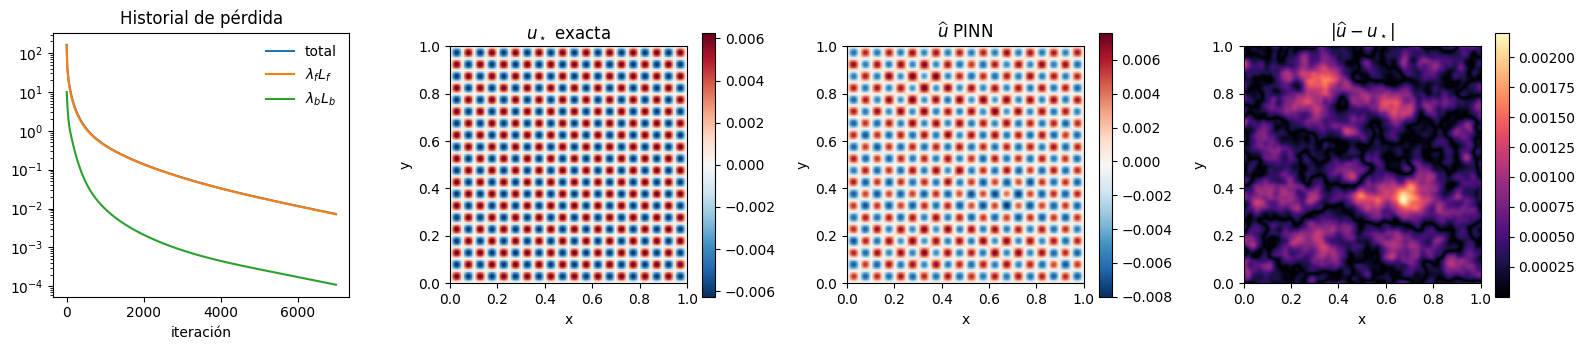

In [ ]:
# Evaluación sobre una malla densa, usada solo para visualizar y validar
n_test = 151
xt = np.linspace(0, 1, n_test)
yt = np.linspace(0, 1, n_test)
XT, YT = np.meshgrid(xt, yt, indexing='xy')

with torch.no_grad():
    U_pred = net(to_col(XT.ravel()), to_col(YT.ravel())).cpu().numpy().reshape(n_test, n_test)
U_true = u_exact_np(XT, YT)
abs_err = np.abs(U_pred - U_true)
rel_l2 = np.sqrt(np.mean((U_pred - U_true)**2)) / np.sqrt(np.mean(U_true**2))
max_err = abs_err.max()

print('='*58)
print(f'error L2 relativo: {rel_l2:.3e}')
print(f'error máximo absoluto: {max_err:.3e}')
print(f'max |u_PINN| = {np.abs(U_pred).max():.3e} | max |u_exacta| = {np.abs(U_true).max():.3e}')
print('='*58)

fig, axs = plt.subplots(1, 4, figsize=(16, 3.6))
axs[0].semilogy(hist['total'], label='total')
axs[0].semilogy(np.array(hist['pde'])*lambda_f, label=r'$\lambda_f L_f$')
axs[0].semilogy(np.array(hist['bc'])*lambda_b, label=r'$\lambda_b L_b$')
axs[0].set_title('Historial de pérdida')
axs[0].set_xlabel('iteración'); axs[0].legend(frameon=False)

im1 = axs[1].imshow(U_true, origin='lower', extent=[0,1,0,1], cmap='RdBu_r')
axs[1].set_title(r'$u_\star$ exacta'); axs[1].set_xlabel('x'); axs[1].set_ylabel('y')
fig.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(U_pred, origin='lower', extent=[0,1,0,1], cmap='RdBu_r')
axs[2].set_title(r'$\widehat u$ PINN'); axs[2].set_xlabel('x'); axs[2].set_ylabel('y')
fig.colorbar(im2, ax=axs[2])

im3 = axs[3].imshow(abs_err, origin='lower', extent=[0,1,0,1], cmap='magma')
axs[3].set_title(r'$|\widehat u-u_\star|$'); axs[3].set_xlabel('x'); axs[3].set_ylabel('y')
fig.colorbar(im3, ax=axs[3])
plt.tight_layout(); plt.show()


## 8. Chequeo independiente del residuo

No basta mirar los puntos usados en entrenamiento. Evaluamos el residuo en puntos nuevos, independientes, para ver si la red aprendió la EDP y no solo memorizó nuestros puntitos, porque tampoco somos animales.


RMSE del residuo en puntos nuevos: 1.298e+00
MAE  del residuo en puntos nuevos: 1.036e+00


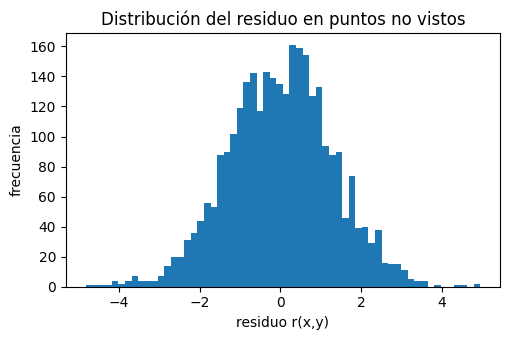

In [ ]:
N_check = 3000
xc = np.random.rand(N_check)
yc = np.random.rand(N_check)
x_c = to_col(xc, requires_grad=True)
y_c = to_col(yc, requires_grad=True)
r_c = poisson_residual(net, x_c, y_c).detach().cpu().numpy().ravel()

print(f'RMSE del residuo en puntos nuevos: {np.sqrt(np.mean(r_c**2)):.3e}')
print(f'MAE  del residuo en puntos nuevos: {np.mean(np.abs(r_c)):.3e}')

plt.figure(figsize=(5.2, 3.5))
plt.hist(r_c, bins=60)
plt.xlabel('residuo r(x,y)')
plt.ylabel('frecuencia')
plt.title('Distribución del residuo en puntos no vistos')
plt.tight_layout(); plt.show()


## 9. Geometría compleja: muestreo sin malla

El texto también menciona dominios con geometrías complicadas: dominios estrellados, agujeros, esquinas reentrantes. Aquí no reentrenamos el modelo; mostramos la parte clave del enfoque: **cambiar la geometría equivale a cambiar el muestreador**, no a construir una malla nueva.

Este bloque genera puntos interiores de una región estrellada con un agujero circular. La misma arquitectura y la misma pérdida se pueden usar allí, cambiando la función de frontera $g$ y el muestreo de $\partial\Omega$.


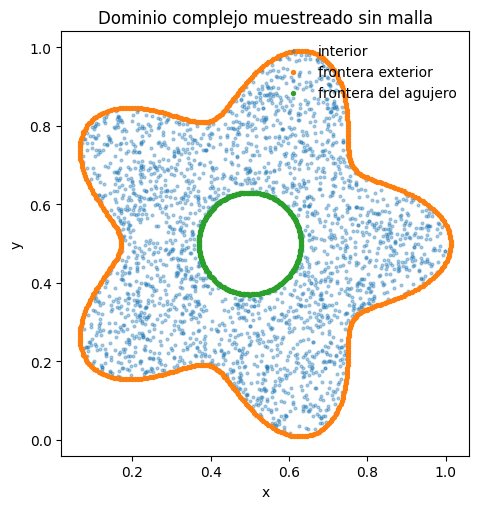

In [ ]:
def star_radius(theta):
    return 0.42 * (1 + 0.22*np.cos(5*theta))

def sample_star_with_hole(n, hole_center=(0.5, 0.5), hole_radius=0.13):
    pts = []
    while len(pts) < n:
        z = np.random.rand(4*n, 2)
        dx = z[:, 0] - 0.5
        dy = z[:, 1] - 0.5
        th = np.arctan2(dy, dx)
        rr = np.sqrt(dx**2 + dy**2)
        inside_star = rr <= star_radius(th)
        outside_hole = (dx**2 + dy**2) >= hole_radius**2
        keep = z[inside_star & outside_hole]
        pts.extend(list(keep))
    return np.array(pts[:n])

def star_boundary(n):
    th = np.linspace(0, 2*np.pi, n, endpoint=False)
    r = star_radius(th)
    return np.c_[0.5 + r*np.cos(th), 0.5 + r*np.sin(th)]

def hole_boundary(n, hole_center=(0.5, 0.5), hole_radius=0.13):
    th = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.c_[hole_center[0] + hole_radius*np.cos(th), hole_center[1] + hole_radius*np.sin(th)]

P_int = sample_star_with_hole(2500)
P_ext = star_boundary(500)
P_hole = hole_boundary(250)

plt.figure(figsize=(5.2, 5.2))
plt.scatter(P_int[:,0], P_int[:,1], s=4, alpha=0.35, label='interior')
plt.scatter(P_ext[:,0], P_ext[:,1], s=8, label='frontera exterior')
plt.scatter(P_hole[:,0], P_hole[:,1], s=8, label='frontera del agujero')
plt.gca().set_aspect('equal')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Dominio complejo muestreado sin malla')
plt.legend(frameon=False, loc='upper right')
plt.tight_layout(); plt.show()


## 10. Conclusiones

Este cuaderno implementa el Ejemplo 1 del capítulo de PINNs siguiendo la cadena:

$$\text{EDP de Poisson}\quad\longrightarrow\quad\text{red }\widehat u(x,y;\theta)\quad\longrightarrow\quad\text{residuo físico + frontera}.$$

La idea central es que la red no aprende solo por datos de solución; aprende porque se le obliga a satisfacer la ecuación diferencial. En este ejemplo:

- el término $\mathcal L_f$ hace que $-\nabla^2\widehat u$ coincida con la fuente $f$;
- el término $\mathcal L_b$ impone la condición de Dirichlet;
- autograd calcula las derivadas de segundo orden sin construir discretizaciones explícitas;
- el muestreo por coordenadas permite trabajar sin malla y abre la puerta a geometrías complicadas.

La advertencia también es la del libro: una PINN no reemplaza mágicamente a FEM o diferencias finitas. Si hay singularidades, capas límite o frecuencias muy altas, puede hacer falta muestreo adaptativo, descomposición de dominio o arquitecturas multiescala. La física ayuda; no hace milagros, aunque a veces se esfuerce por parecerlo.
